In [95]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm
import pickle
import os
from collections import defaultdict
from sklearn.preprocessing import MinMaxScaler
from torch.utils.data import Dataset, DataLoader

In [96]:
class SwinehartAbbottNetworkMultiLayer(nn.Module):
    def __init__(self, L1_size, L2_size, L3_size, init_gain, init_shift, alpha, connect_prob=0.9, manual_weights=None):
        super(SwinehartAbbottNetworkMultiLayer, self).__init__()

        self.L1_size = L1_size
        self.L1_gains = nn.Parameter(torch.full((L1_size, 1), init_gain, dtype=torch.float32))
        self.L1_shifts = nn.Parameter(torch.full((L1_size, 1), init_shift, dtype=torch.float32))
        init_L1_weight = (1 / L1_size) * int(L1_size * alpha)
        self.alpha = alpha
        if manual_weights is None:
            init_L1_weights = torch.rand((L2_size, L1_size), dtype=torch.float32)
            init_L1_weights /= init_L1_weights.sum(dim=1, keepdim=True)
            L1_weights = init_L1_weights * int(L1_size * alpha)
            L1_mask = torch.from_numpy(np.random.choice([1, 0], size=L1_weights.shape, p=[connect_prob, 1 - connect_prob])).float()
        else:
            L1_weights = torch.from_numpy(manual_weights['L1_weights']).float()
            L1_mask = torch.from_numpy(manual_weights['L1_mask']).float()
        
        self.register_buffer('L1_weights', L1_weights)
        self.register_buffer('L1_mask', L1_mask)

        self.L2_size = L2_size
        self.L2_gains = nn.Parameter(torch.full((L2_size, 1), init_gain, dtype=torch.float32))
        self.L2_shifts = nn.Parameter(torch.full((L2_size, 1), init_shift, dtype=torch.float32))
        if manual_weights is None:
            init_L2_weights = torch.rand((L3_size, L2_size), dtype=torch.float32)
            init_L2_weights /= init_L2_weights.sum(dim=1, keepdim=True)
            L2_weights = init_L2_weights * int(L2_size * alpha)
            L2_mask = torch.from_numpy(np.random.choice([1, 0], size=L2_weights.shape, p=[connect_prob, 1 - connect_prob])).float()
        else:
            L2_weights = torch.from_numpy(manual_weights['L2_weights']).float()
            L2_mask = torch.from_numpy(manual_weights['L2_mask']).float()

        self.register_buffer('L2_weights', L2_weights)
        self.register_buffer('L2_mask', L2_mask)

        self.L3_size = L3_size
        self.L3_gains = nn.Parameter(torch.full((L3_size,), init_gain, dtype=torch.float32, requires_grad=False))
        self.L3_shifts = nn.Parameter(torch.full((L3_size,), init_shift, dtype=torch.float32, requires_grad=False))

        self.activation_func = nn.Sigmoid()

    def normal_pdf(self, theta):
        return 1.5 * torch.exp(-(theta ** 2) / 2) - 0.5
    
    def gaussian_rf(self, x):
        theta_is = torch.linspace(0, 2 * torch.pi, self.L1_size, device=x.device).view(-1, 1)
        return self.normal_pdf(x - theta_is) + self.normal_pdf(x - theta_is + 2 * torch.pi) + self.normal_pdf(x - theta_is - 2 * torch.pi)

    def forward(self, stimulus):
        L1_inputs = self.gaussian_rf(stimulus)

        L1_activations = self.activation_func(self.L1_gains * (L1_inputs - self.L1_shifts))
        L1_mat = torch.mul(self.L1_weights, self.L1_mask)  # binary connection mask
        L2_inputs = torch.matmul(L1_mat, L1_activations)

        L2_activations = self.activation_func(self.L2_gains * (L2_inputs - self.L2_shifts))
        L2_mat = torch.mul(self.L2_weights, self.L2_mask)  # binary connection mask
        L3_inputs = torch.matmul(L2_mat, L2_activations)  # If we were to keep adding layers these would be added on

        # Save Vars
        self.L1_inputs = L1_inputs.clone()
        self.L1_activations = L1_activations.clone()
        self.L2_inputs = L2_inputs.clone()
        self.L2_activations = L2_activations.clone()
        self.L3_activations = L3_inputs.clone()

        return L3_inputs


In [97]:
def get_dataloader(batch_size):
    return DataLoader(dataset, batch_size=batch_size, shuffle=True)

class CustomDataset(Dataset):
    def __init__(self, xs, target_outputs):
        self.xs = xs
        self.target_outputs = target_outputs

    def __len__(self):
        return len(self.xs)

    def __getitem__(self, idx):
        x = self.xs[idx]
        target = self.target_outputs[:, idx]
        return x, target

In [115]:
L1_size = 200
L2_size = 150 
L3_size = 20 
init_gain = 3
init_shift = 1
conProb = 0.3 
alpha = 0.25 # defines the fraction of the layer size
L1_alpha = int(L1_size * alpha) 
L2_alpha = int(L2_size * alpha) 
torch.manual_seed(42)

# Check if GPU is available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Data Generation
ndata = 50
xs = torch.linspace(0, 2 * torch.pi, ndata).to(device)

output_targ_shifts = torch.linspace(0, 2 * torch.pi, L3_size).to(device)
target_outputs = torch.zeros((L3_size, ndata)).to(device)
for ind, shift in enumerate(output_targ_shifts):
    target_outputs[ind, :] = torch.cos(xs - shift) / 4 + 0.5 # Make the target outputs many shifted cosines

# Create dataset
dataset = CustomDataset(xs, target_outputs)

# Function to create DataLoader with specific batch size
def get_dataloader(batch_size):
    return DataLoader(dataset, batch_size=batch_size, shuffle=True)

# Training Params
num_epochs = 2000
controller_lr = 0.001 # 0.2
hebbian_lr = 0.9 # 0.009

has_controller = True
has_hebbian = True

# Establish Model
MultiModel = SwinehartAbbottNetworkMultiLayer(L1_size, L2_size, L3_size, init_gain, init_shift, alpha, connect_prob=conProb).to(device)
loss_func = nn.MSELoss()
#optimizer = optim.SGD([MultiModel.L1_gains, MultiModel.L1_shifts, MultiModel.L2_gains, MultiModel.L2_shifts, MultiModel.L3_gains, MultiModel.L3_shifts], lr=controller_lr)
optimizer = optim.Adam([MultiModel.L1_gains, MultiModel.L1_shifts, MultiModel.L2_gains, MultiModel.L2_shifts, MultiModel.L3_gains, MultiModel.L3_shifts], lr=controller_lr)

# Dynamic batch size schedule
initial_batch_size = 16
min_batch_size = 2
batch_size_decrement = (initial_batch_size - min_batch_size) / num_epochs

for epoch in range(num_epochs):
    # Calculate current batch size
    current_batch_size = initial_batch_size #max(int(initial_batch_size - epoch * batch_size_decrement), min_batch_size)
    dataloader = get_dataloader(current_batch_size)

    epoch_loss = 0

    for batch in dataloader:
        xs_batch, targets_batch = batch
        xs_batch, targets_batch = xs_batch.to(device), targets_batch.to(device)

        # Forward
        L3_activations = MultiModel(xs_batch)
        output = L3_activations

        # Calculate loss
        loss = 0.5 * loss_func(output, targets_batch.T)  # Ensure targets_batch matches output shape
        epoch_loss += loss.item()

        # Backprop for gains and shifts
        if has_controller:
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        # Hebbian learning for weights
        if has_hebbian:
            L1_hebbian_update = MultiModel.L2_activations @ MultiModel.L1_activations.T  # Adjust matrix multiplication
            L2_hebbian_update = MultiModel.L3_activations @ MultiModel.L2_activations.T  # Adjust matrix multiplication

            with torch.no_grad():
                MultiModel.L1_weights += L1_hebbian_update.mean(dim=0) * hebbian_lr
                MultiModel.L1_weights /= torch.sum(MultiModel.L1_weights, dim=1, keepdim=True)
                MultiModel.L1_weights *= L1_alpha

                MultiModel.L2_weights += L2_hebbian_update.mean(dim=0) * hebbian_lr
                MultiModel.L2_weights /= torch.sum(MultiModel.L2_weights, dim=1, keepdim=True)
                MultiModel.L2_weights *= L2_alpha

    # Print Losses
    epoch_loss /= len(dataloader)
    if (epoch + 1) % 10 == 0:
        print(f"Epoch: {epoch}, Loss: {epoch_loss}.")


Epoch: 9, Loss: 0.03647390101104975.
Epoch: 19, Loss: 0.02282110136002302.
Epoch: 29, Loss: 0.018760701175779104.
Epoch: 39, Loss: 0.017469871789216995.
Epoch: 49, Loss: 0.0170133076608181.
Epoch: 59, Loss: 0.01674831612035632.
Epoch: 69, Loss: 0.01651899004355073.
Epoch: 79, Loss: 0.01614791015163064.
Epoch: 89, Loss: 0.016248795203864574.
Epoch: 99, Loss: 0.01580841699615121.
Epoch: 109, Loss: 0.015845661517232656.
Epoch: 119, Loss: 0.01602425263263285.
Epoch: 129, Loss: 0.015714300330728292.
Epoch: 139, Loss: 0.015485453652217984.
Epoch: 149, Loss: 0.015491851838305593.
Epoch: 159, Loss: 0.015572869684547186.
Epoch: 169, Loss: 0.015715487767010927.
Epoch: 179, Loss: 0.015460192924365401.
Epoch: 189, Loss: 0.015504391863942146.
Epoch: 199, Loss: 0.015303530031815171.
Epoch: 209, Loss: 0.01529672252945602.
Epoch: 219, Loss: 0.015262154629454017.
Epoch: 229, Loss: 0.015083995182067156.
Epoch: 239, Loss: 0.015014242148026824.
Epoch: 249, Loss: 0.014978664461523294.
Epoch: 259, Loss: 0.0

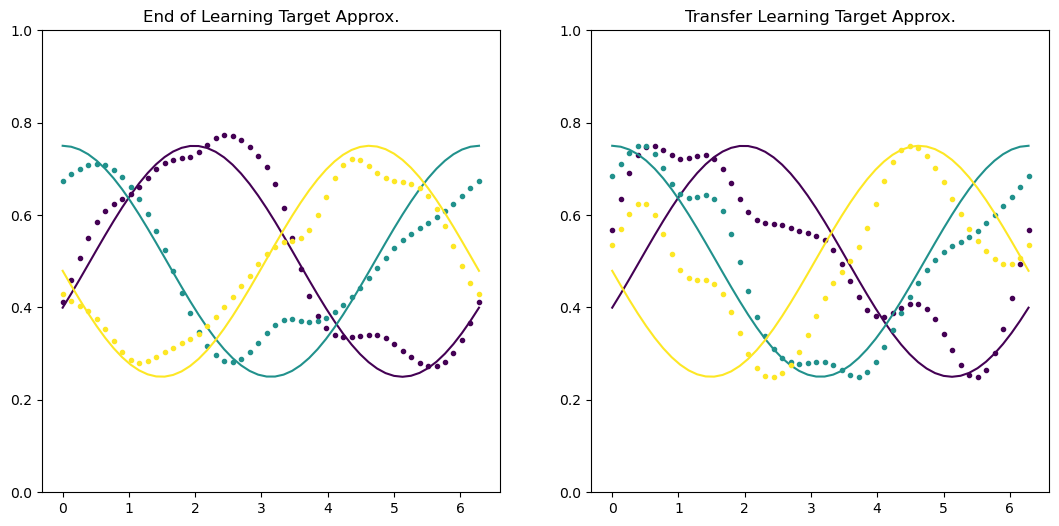

In [116]:
# POST TRAINING ---------------------
manual_weights = {}
manual_weights['L1_weights'] = MultiModel.L1_weights.detach().cpu().numpy().squeeze()
manual_weights['L1_mask'] = MultiModel.L1_mask.detach().cpu().numpy().squeeze()
manual_weights['L2_weights'] = MultiModel.L2_weights.detach().cpu().numpy().squeeze()
manual_weights['L2_mask'] = MultiModel.L2_mask.detach().cpu().numpy().squeeze()

with torch.no_grad():
    final_outputs = MultiModel(xs).detach().cpu().numpy().squeeze()

new_MultiModel = SwinehartAbbottNetworkMultiLayer(L1_size, L2_size, L3_size, init_gain, init_shift, alpha, connect_prob=conProb, manual_weights=manual_weights).to(device)
transferLearning_outputs = new_MultiModel(xs).detach().cpu().numpy().squeeze()


num_units_sample = 3
np.random.seed(42)
samp_inds = np.random.randint(0, L3_size, num_units_sample) #np.linspace(0, output_size-1, num_units_sample).astype(int)
colors = plt.cm.viridis(np.linspace(0, 1, num_units_sample))  


scaler = MinMaxScaler(feature_range=(torch.min(target_outputs.cpu()).numpy(), torch.max(target_outputs.cpu()).numpy()))  

plt.figure(figsize=(13, 6))

plt.subplot(1,2,1)
plt.title("End of Learning Target Approx.")
for i, targ_ind in enumerate(samp_inds):

    plt.plot(xs.cpu(), target_outputs.cpu()[targ_ind, :], color=colors[i])
    plt.plot(xs.cpu(), final_outputs[targ_ind, :], '.', color=colors[i])
    plt.ylim([0, 1])



plt.subplot(1,2,2)
plt.title("Transfer Learning Target Approx.")
for i, targ_ind in enumerate(samp_inds):
    
    plt.plot(xs.cpu(), target_outputs.cpu()[targ_ind, :], color=colors[i])

    outputs_to_plot = scaler.fit_transform(transferLearning_outputs[targ_ind, :].reshape(-1, 1)) #scaler.fit_transform(transferLearning_outputs[targ_ind, :].view(-1, 1))
    plt.plot(xs.cpu(), outputs_to_plot, '.', color=colors[i])
    #plt.plot(xs, transferLearning_outputs[targ_ind, :], '.', color=colors[i])
    plt.ylim([0, 1])


